In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("IPL_ball_by_ball_updated.csv")
df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (243815, 22)

Columns:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

Data Types:
match_id                    int64
season                      int64
start_date                 object
venue                      object
innings                     int64
ball                      float64
batting_team               object
bowling_team               object
striker                    object
non_striker                object
bowler                     object
runs_off_bat                int64
extras                      int64
wides                     float64
noballs                   float64
byes                      float64
legbyes                   float64
penalty                   float64
wicket_type                object
player_dismissed    

In [4]:
missing_values = df.isnull().sum()
print(missing_values)

match_id                       0
season                         0
start_date                     0
venue                          0
innings                        0
ball                           0
batting_team                   0
bowling_team                   0
striker                        0
non_striker                    0
bowler                         0
runs_off_bat                   0
extras                         0
wides                     236163
noballs                   242797
byes                      243187
legbyes                   240037
penalty                   243813
wicket_type               231748
player_dismissed          231748
other_wicket_type         243815
other_player_dismissed    243815
dtype: int64


In [5]:
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicate rows removed:", before - after)

Rows before removing duplicates: 243815
Rows after removing duplicates: 243815
Duplicate rows removed: 0


In [6]:
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")

features = [
    "season",
    "innings",
    "ball",
    "extras",
    "wides",
    "noballs",
    "byes",
    "legbyes",
    "penalty"
]
target = "runs_off_bat"

# These extra-related columns are sparse by design:
# when a particular extra did not occur, a missing value represents zero.
for col in ["wides", "noballs", "byes", "legbyes", "penalty"]:
    df[col] = df[col].fillna(0)

df = df.dropna(subset=features + [target]).copy()

print("Selected features:", features)
print("Target:", target)
print("Prepared dataset shape:", df.shape)

Selected features: ['season', 'innings', 'ball', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty']
Target: runs_off_bat
Prepared dataset shape: (243815, 22)


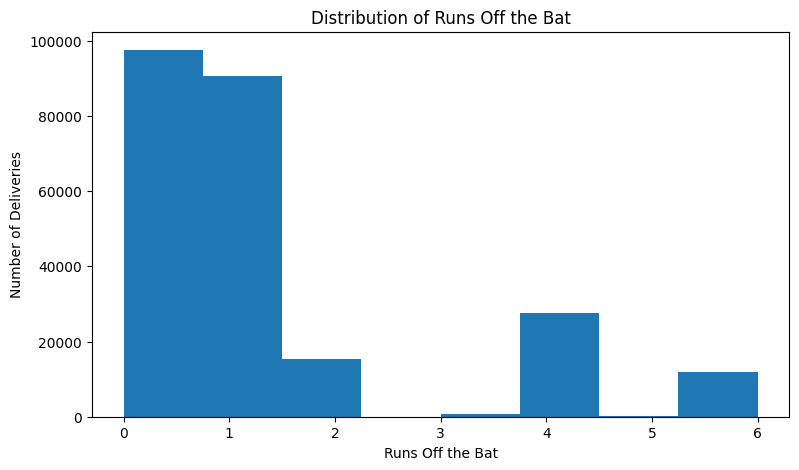

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(df["runs_off_bat"], bins=8)
plt.title("Distribution of Runs Off the Bat")
plt.xlabel("Runs Off the Bat")
plt.ylabel("Number of Deliveries")
plt.show()

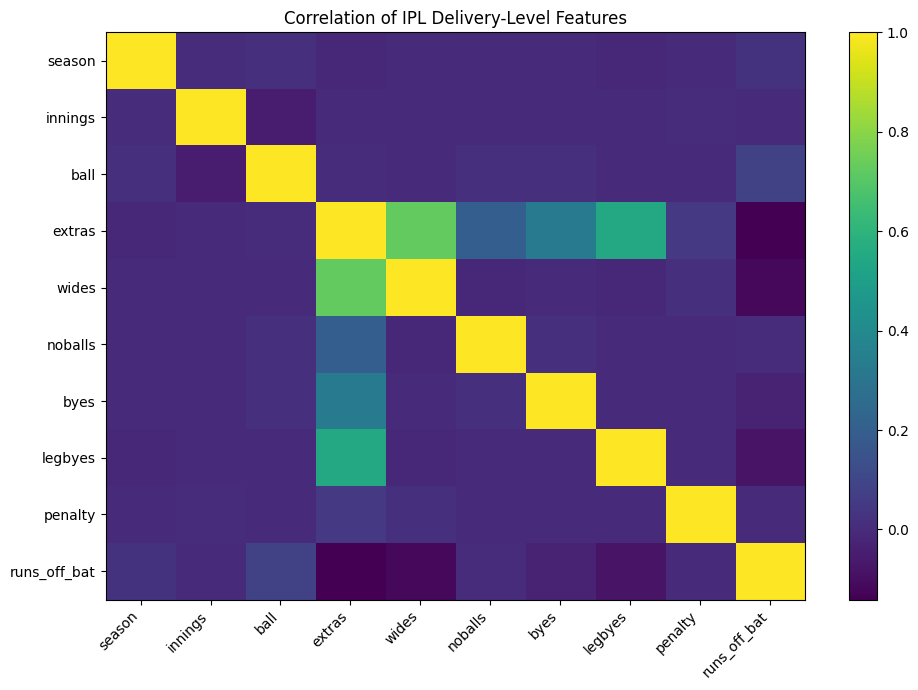

In [8]:
corr = df[features + [target]].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation of IPL Delivery-Level Features")
plt.tight_layout()
plt.show()

In [9]:
X = df[features]
y = df[target]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 input records:")
display(X.head())
print("\nFirst 5 target values:")
display(y.head())

Input shape: (243815, 9)
Target shape: (243815,)

First 5 input records:


,season,innings,ball,extras,wides,noballs,byes,legbyes,penalty
0,2008,1,0.1,1,0.0,0.0,0.0,1.0,0.0
1,2008,1,0.2,0,0.0,0.0,0.0,0.0,0.0
2,2008,1,0.3,1,1.0,0.0,0.0,0.0,0.0
3,2008,1,0.4,0,0.0,0.0,0.0,0.0,0.0
4,2008,1,0.5,0,0.0,0.0,0.0,0.0,0.0



First 5 target values:


0    0
1    0
2    0
3    0
4    0
Name: runs_off_bat, dtype: int64

In [10]:
# A fixed sample keeps Random Forest training practical while retaining reproducibility.
sample_size = min(50000, len(df))
model_df = df.sample(n=sample_size, random_state=42)

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 40000
Testing records: 10000


In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Random Forest model trained successfully")

Random Forest model trained successfully


In [12]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Runs": y_test.to_numpy()[:15],
    "Predicted Runs": np.round(y_pred[:15], 2)
})

comparison

,Actual Runs,Predicted Runs
0,0,0.33
1,0,1.55
2,0,0.54
3,0,0.88
4,6,1.95
5,1,1.95
6,0,0.52
7,1,1.87
8,1,1.51
9,0,0.62


In [13]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.2056
R² Score: -0.0814


In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
2,ball,0.483929
0,season,0.304232
3,extras,0.107720
1,innings,0.092753
5,noballs,0.011348
7,legbyes,0.000016
6,byes,0.000001
4,wides,0.000000
8,penalty,0.000000
